## Dataset Description

The dataset contains information about used cars, including:

- Name: Name of the car
- Year: Manufacturing year
- Selling Price: Selling price of the car
- Kilometers Driven: Total distance driven
- Fuel: Type of fuel used
- Seller Type: Type of seller
- Transmission: Manual or Automatic
- Owner: Number/type of previous owners

The target variable for this project is **selling_price**.

In [1]:
# Import required libraries

import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Regression models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Model evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [6]:
# Load the dataset

df = pd.read_csv("CAR DETAILS FROM CAR DEKHO.csv")
# Display first 5 rows
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [7]:
# Check the shape of the dataset
print("Dataset Shape:", df.shape)

# Check column names
print("\nColumns:")
print(df.columns.tolist())

# Basic information about the dataset
df.info()

Dataset Shape: (4340, 8)

Columns:
['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


In [8]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())

# Check for duplicate rows
print("\nDuplicate Rows:", df.duplicated().sum())

Missing Values:
name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

Duplicate Rows: 763


In [9]:
# Remove duplicate rows
df = df.drop_duplicates()

# Check the new dataset shape
print("Dataset Shape after removing duplicates:", df.shape)

# Check duplicates again
print("Duplicate Rows:", df.duplicated().sum())

Dataset Shape after removing duplicates: (3577, 8)
Duplicate Rows: 0


In [10]:
# Check unique values in categorical columns

categorical_columns = ['fuel', 'seller_type', 'transmission', 'owner']

for column in categorical_columns:
    print(f"\n{column.upper()}:")
    print(df[column].unique())


FUEL:
['Petrol' 'Diesel' 'CNG' 'LPG' 'Electric']

SELLER_TYPE:
['Individual' 'Dealer' 'Trustmark Dealer']

TRANSMISSION:
['Manual' 'Automatic']

OWNER:
['First Owner' 'Second Owner' 'Fourth & Above Owner' 'Third Owner'
 'Test Drive Car']


In [11]:
# Get the current year
current_year = 2026

# Create a new feature: car_age
df['car_age'] = current_year - df['year']

# Display the first 5 rows
df[['name', 'year', 'car_age']].head()

,name,year,car_age
0,Maruti 800 AC,2007,19
1,Maruti Wagon R LXI Minor,2007,19
2,Hyundai Verna 1.6 SX,2012,14
3,Datsun RediGO T Option,2017,9
4,Honda Amaze VX i-DTEC,2014,12


In [12]:
# Extract the first word from the car name as the brand
df['brand'] = df['name'].str.split().str[0]

# Display name and brand
df[['name', 'brand']].head(10)

,name,brand
0,Maruti 800 AC,Maruti
1,Maruti Wagon R LXI Minor,Maruti
2,Hyundai Verna 1.6 SX,Hyundai
3,Datsun RediGO T Option,Datsun
4,Honda Amaze VX i-DTEC,Honda
5,Maruti Alto LX BSIII,Maruti
6,Hyundai Xcent 1.2 Kappa S,Hyundai
7,Tata Indigo Grand Petrol,Tata
8,Hyundai Creta 1.6 VTVT S,Hyundai
9,Maruti Celerio Green VXI,Maruti


In [13]:
# Display dataset columns
print(df.columns)

# Display the first 5 rows
df.head()

Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner', 'car_age', 'brand'],
      dtype='object')


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,car_age,brand
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner,19,Maruti
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner,19,Maruti
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner,14,Hyundai
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner,9,Datsun
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner,12,Honda


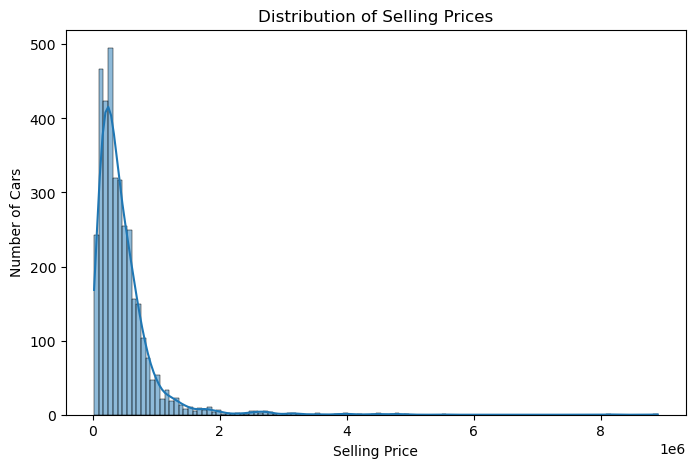

In [14]:
# Set the figure size
plt.figure(figsize=(8, 5))

# Distribution plot of selling price
sns.histplot(df['selling_price'], kde=True)

plt.title('Distribution of Selling Prices')
plt.xlabel('Selling Price')
plt.ylabel('Number of Cars')

plt.show()

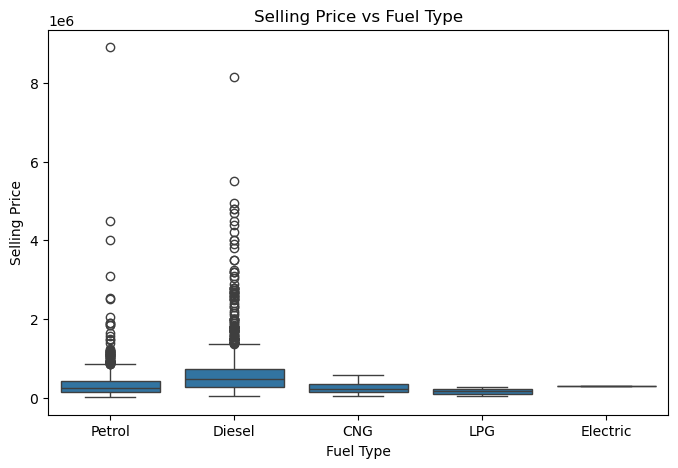

In [15]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='fuel',
    y='selling_price'
)

plt.title('Selling Price vs Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Selling Price')

plt.show()

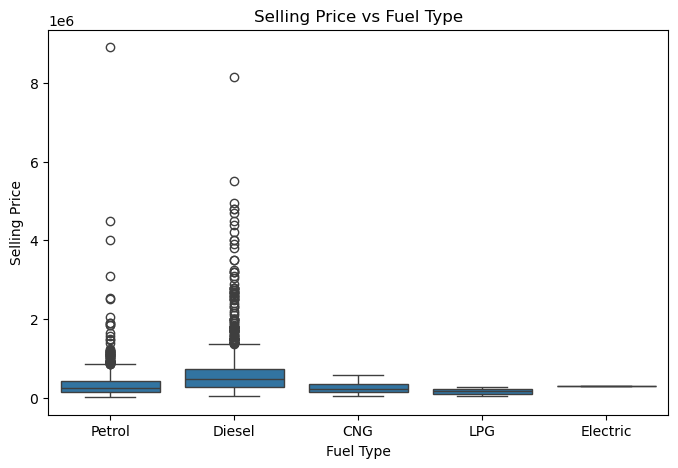

In [16]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='fuel',
    y='selling_price'
)

plt.title('Selling Price vs Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Selling Price')

plt.show()

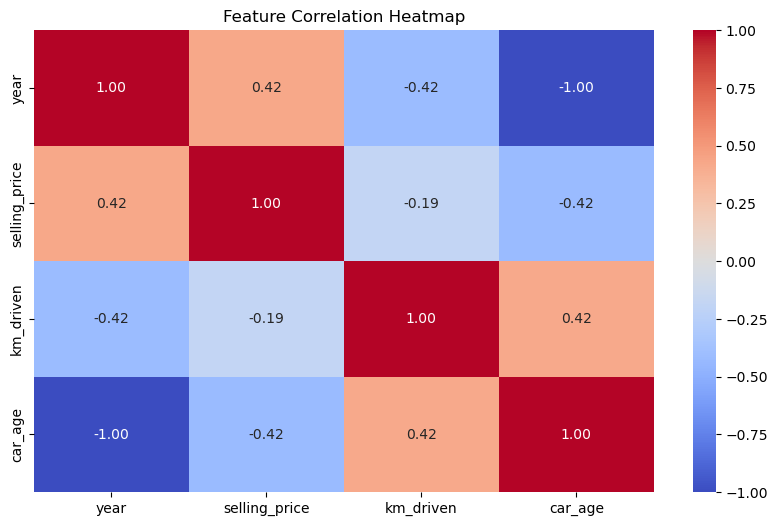

In [17]:
# Select numerical columns
numerical_df = df.select_dtypes(include=['int64', 'float64'])

# Display correlation matrix
correlation_matrix = numerical_df.corr()

# Create the heatmap
plt.figure(figsize=(10, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Feature Correlation Heatmap')

plt.show()

In [18]:
# Define features (X) and target variable (y)

X = df.drop(columns=['selling_price', 'name'])

y = df['selling_price']

print("Features:")
print(X.columns)

print("\nTarget:")
print(y.name)

Features:
Index(['year', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner',
       'car_age', 'brand'],
      dtype='object')

Target:
selling_price


In [19]:
# Identify categorical columns
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

# Identify numerical columns
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Categorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)

Categorical Features:
['fuel', 'seller_type', 'transmission', 'owner', 'brand']

Numerical Features:
['year', 'km_driven', 'car_age']


In [20]:
# Create a preprocessor for categorical and numerical features

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numerical_features)
    ]
)

In [21]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (2861, 8)
Testing Data Shape: (716, 8)


In [22]:
# Create Linear Regression pipeline

linear_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]
)

# Train the model
linear_model.fit(X_train, y_train)

# Make predictions
y_pred_linear = linear_model.predict(X_test)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [23]:
# Calculate evaluation metrics

mae_linear = mean_absolute_error(y_test, y_pred_linear)

rmse_linear = np.sqrt(
    mean_squared_error(y_test, y_pred_linear)
)

r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression Performance")
print("-----------------------------")
print("MAE:", mae_linear)
print("RMSE:", rmse_linear)
print("R² Score:", r2_linear)

Linear Regression Performance
-----------------------------
MAE: 206391.03087499193
RMSE: 431742.0185374333
R² Score: 0.421354020104183


In [24]:
# Create Random Forest pipeline

rf_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', RandomForestRegressor(
            n_estimators=100,
            random_state=42
        ))
    ]
)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [25]:
# Calculate evaluation metrics

mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(
    mean_squared_error(y_test, y_pred_rf)
)

r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Performance")
print("--------------------------")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R² Score:", r2_rf)

Random Forest Performance
--------------------------
MAE: 159864.97987654127
RMSE: 368735.94465221575
R² Score: 0.5779195324547102


In [26]:
# Create a comparison table

results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest Regressor'
    ],
    'MAE': [
        mae_linear,
        mae_rf
    ],
    'RMSE': [
        rmse_linear,
        rmse_rf
    ],
    'R² Score': [
        r2_linear,
        r2_rf
    ]
})

results

,Model,MAE,RMSE,R² Score
0,Linear Regression,206391.030875,431742.018537,0.421354
1,Random Forest Regressor,159864.979877,368735.944652,0.577920


In [27]:
# Find the best model based on R² Score

best_model_name = results.loc[
    results['R² Score'].idxmax(),
    'Model'
]

print("Best Model:", best_model_name)

Best Model: Random Forest Regressor


In [28]:
# Get the trained preprocessor
trained_preprocessor = rf_model.named_steps['preprocessor']

# Get the trained Random Forest model
trained_rf = rf_model.named_steps['model']

# Get feature names after One-Hot Encoding
feature_names = trained_preprocessor.get_feature_names_out()

# Get feature importance values
importances = trained_rf.feature_importances_

# Create a DataFrame
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sort features by importance
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

# Display top 15 important features
feature_importance.head(15)

,Feature,Importance
8,cat__transmission_Manual,0.133566
42,num__km_driven,0.130885
41,num__year,0.117851
7,cat__transmission_Automatic,0.110460
43,num__car_age,0.109083
1,cat__fuel_Diesel,0.072687
15,cat__brand_Audi,0.052229
3,cat__fuel_Petrol,0.041266
27,cat__brand_Land,0.040273
38,cat__brand_Toyota,0.037104


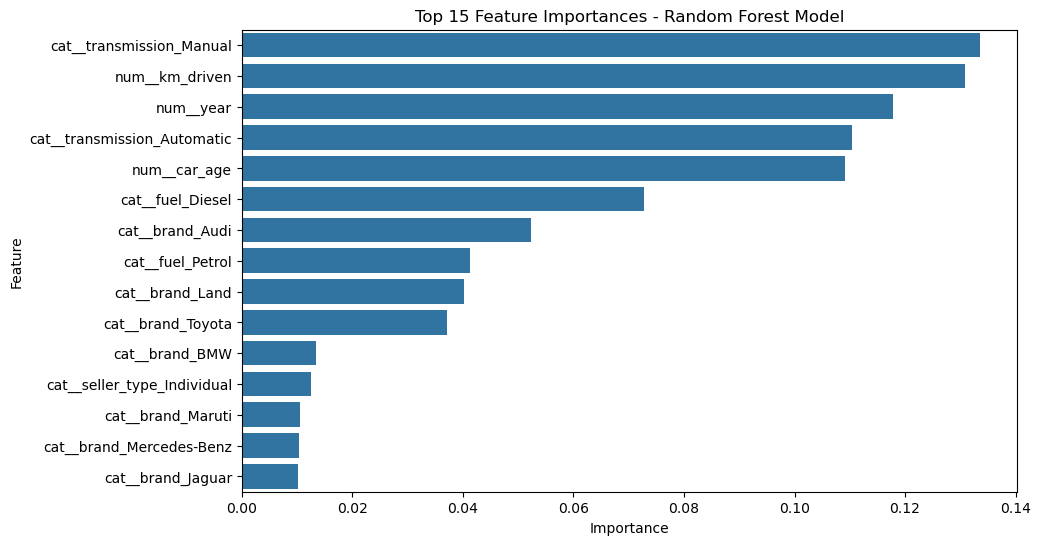

In [29]:
# Select top 15 features
top_features = feature_importance.head(15)

# Create the chart
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature'
)

plt.title('Top 15 Feature Importances - Random Forest Model')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.show()

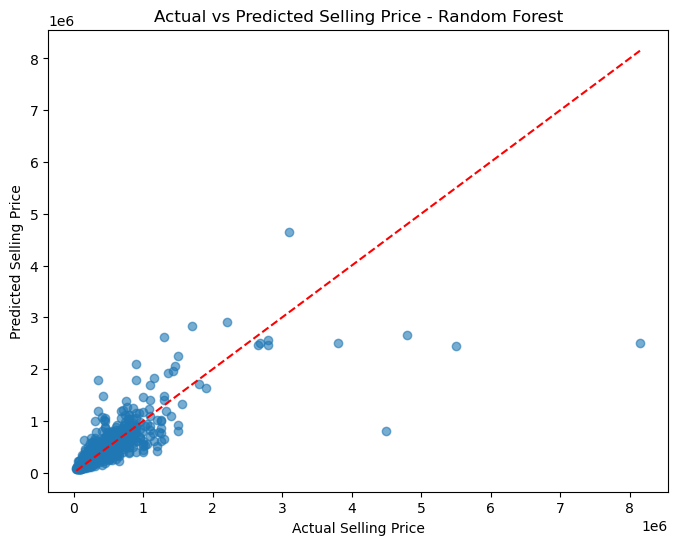

In [30]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_rf,
    alpha=0.6
)

plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price')
plt.title('Actual vs Predicted Selling Price - Random Forest')

# Add reference line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.show()

## Conclusion

In this project, a machine learning regression model was developed to predict the selling price of used cars.

The dataset was cleaned by removing duplicate records, and new features such as car age and brand were created.

Exploratory Data Analysis was performed to understand the relationship between selling price and different features.

Two regression models were trained:

1. Linear Regression
2. Random Forest Regressor

The models were evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

The model with the highest R² Score was selected as the best-performing model.

Feature importance analysis was also performed to identify which features had the greatest influence on the predicted selling price.